## This notebook links KO-level functional signals with FluRICo structural microbial groups, then evaluates module-level associations and external cohort consistency.

In [1]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import tqdm
from joblib import load,dump
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tqdm import tqdm
np.random.seed(888)

In [2]:
df_info = pd.read_csv("data/Unigenes.KEGG.tax.xls", sep="\t")
tax = pd.read_csv('data/taxonomy.csv')

In [3]:
df_mb = pd.read_csv('data/microbe_train.csv',index_col=0)

In [4]:
full_name_dic = {}
for i in range(len(tax)):
    full_name_dic[tax['ID'][i]] = tax['Taxonomy'][i]

### Overlap and prepare data for WGCNA

In [5]:
score_hc_mb = pd.read_csv('results/flurico_results/microbe_summary_HC.csv',index_col=0)
score_mia_mb = pd.read_csv('results/flurico_results/microbe_summary_MIA.csv',index_col=0)
score_ia_mb = pd.read_csv('results/flurico_results/microbe_summary_IA.csv',index_col=0)

score_hc_mt = pd.read_csv('results/flurico_results/metabolite_summary_HC.csv',index_col=0)
score_mia_mt = pd.read_csv('results/flurico_results/metabolite_summary_MIA.csv',index_col=0)
score_ia_mt = pd.read_csv('results/flurico_results/metabolite_summary_IA.csv',index_col=0)

In [6]:
def find_top_features(df, top_n=50, top_n_dic=None):
    if top_n_dic is None:
        top_n_dic = {}

    dim_map = {
        'flu_le': 'Fluctuation_Levene',
        'flu_fc_ea': 'Fluctuation_FC_HC_vs_MIA',
        'flu_fc_la': 'Fluctuation_FC_MIA_vs_IA',
        'flu_fc_gl': 'Fluctuation_FC_HC_vs_IA',
        'ri': 'Remote_Interaction',
        'ri_tr_pos_c': 'Remote_Trend_Pos_Count',
        'ri_tr_neg_c': 'Remote_Trend_Neg_Count',
        'co': 'Coordination'
    }

    result = {}
    for key, col in dim_map.items():
        n = top_n_dic.get(key, top_n)
        result[key] = df.nlargest(n, col, keep='all')[col].to_dict()

    return result


def ordered_union(*lists):
    seen = set()
    out = []
    for lst in lists:
        for x in lst:
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out


def build_feature_lists(score_hc, score_mia, score_ia, top_n):
    rank_dict = {
        'hc': find_top_features(score_hc, top_n=top_n),
        'mia': find_top_features(score_mia, top_n=top_n),
        'ia': find_top_features(score_ia, top_n=top_n)
    }

    union_dict = {
        dim: ordered_union(
            list(rank_dict['hc'][dim].keys()),
            list(rank_dict['mia'][dim].keys()),
            list(rank_dict['ia'][dim].keys())
        )
        for dim in rank_dict['hc']
    }

    dy_list = ordered_union(
        union_dict['flu_le'],
        union_dict['flu_fc_ea'],
        union_dict['flu_fc_la'],
        union_dict['flu_fc_gl'],
        union_dict['ri_tr_pos_c'],
        union_dict['ri_tr_neg_c']
    )

    st_list = ordered_union(
        union_dict['ri'],
        union_dict['co']
    )

    return rank_dict, union_dict, dy_list, st_list

In [7]:
mb_rank, mb_union, mb_dy_list, mb_st_list = build_feature_lists(
    score_hc_mb, score_mia_mb, score_ia_mb, top_n=50
)


In [8]:
structure_mb = {'HC':ordered_union(mb_rank['hc']['ri'],mb_rank['hc']['co']),
                'MIA':ordered_union(mb_rank['mia']['ri'],mb_rank['mia']['co']),
                'IA':ordered_union(mb_rank['ia']['ri'],mb_rank['ia']['co']),}

In [9]:
def build_structure_koid(structure_mb, full_name_dic, df_info):
    koid_dict_by_cond = {}
    koid_list_by_cond = {}

    for cond in ['HC', 'MIA', 'IA']:
        core_mb = structure_mb[cond]
        core_mb_koid = {}
        core_mb_koid_list = []

        for i in tqdm(core_mb, desc=f'{cond} KO mapping'):
            full_name = full_name_dic[i]
            lookup = df_info[df_info['Taxonomy'] == full_name]
            ko_list = list(set(lookup['KO_ID'].tolist()))

            core_mb_koid[i] = ko_list
            core_mb_koid_list.extend(ko_list)

        core_mb_koid_list = ordered_union(core_mb_koid_list)

        koid_dict_by_cond[cond] = core_mb_koid
        koid_list_by_cond[cond] = core_mb_koid_list

    return koid_dict_by_cond, koid_list_by_cond

In [10]:
st_mb_koid, st_mb_ko = build_structure_koid(
    structure_mb=structure_mb,
    full_name_dic=full_name_dic,
    df_info=df_info
)

IA KO mapping: 100%|██████████| 98/98 [00:07<00:00, 12.66it/s]


In [11]:
from matplotlib_venn import venn3, venn3_circles

def plot_venn3_equal_return(list1, list2, list3,
                            set1_label="A", set2_label="B", set3_label="C",
                            title=None,
                            save_path=None):

    set1, set2, set3 = set(list1), set(list2), set(list3)

    all_shared = set1 & set2 & set3
    ab_shared = (set1 & set2) - all_shared
    ac_shared = (set1 & set3) - all_shared
    bc_shared = (set2 & set3) - all_shared
    a_unique = set1 - set2 - set3
    b_unique = set2 - set1 - set3
    c_unique = set3 - set1 - set2

    plt.figure(figsize=(7, 6), dpi=500)
    venn = venn3(subsets=(1, 1, 1, 1, 1, 1, 1),
                 set_labels=(set1_label, set2_label, set3_label),
                 set_colors=('#f3c498', '#c3d8b7', '#99c9e3'),
                 alpha=0.9)

    label_map = {
        '100': len(a_unique),
        '010': len(b_unique),
        '001': len(c_unique),
        '110': len(ab_shared),
        '101': len(ac_shared),
        '011': len(bc_shared),
        '111': len(all_shared)
    }

    number_font_size = 20
    for key, val in label_map.items():
        label = venn.get_label_by_id(key)
        if label:
            label.set_text(str(val))
            label.set_fontsize(number_font_size)

    venn3_circles(subsets=(1, 1, 1, 1, 1, 1, 1), color='#b0b0b0', linewidth=2)
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=500, bbox_inches='tight')


    plt.show()

    region_name_map = {
        f"{set1_label}": a_unique,
        f"{set2_label}": b_unique,
        f"{set3_label}": c_unique,
        f"{set1_label}&{set2_label}": ab_shared,
        f"{set1_label}&{set3_label}": ac_shared,
        f"{set2_label}&{set3_label}": bc_shared,
        f"{set1_label}&{set2_label}&{set3_label}": all_shared,
    }

    ko_to_region = {}
    for region_name, region_set in region_name_map.items():
        for ko in region_set:
            ko_to_region[ko] = region_name

    return {
        "unique": {
            set1_label: list(a_unique),
            set2_label: list(b_unique),
            set3_label: list(c_unique)
        },
        "pairwise_shared": {
            f"{set1_label}-{set2_label}": list(ab_shared),
            f"{set1_label}-{set3_label}": list(ac_shared),
            f"{set2_label}-{set3_label}": list(bc_shared)
        },
        "all_shared": list(all_shared),
        "ko_to_region": ko_to_region
    }

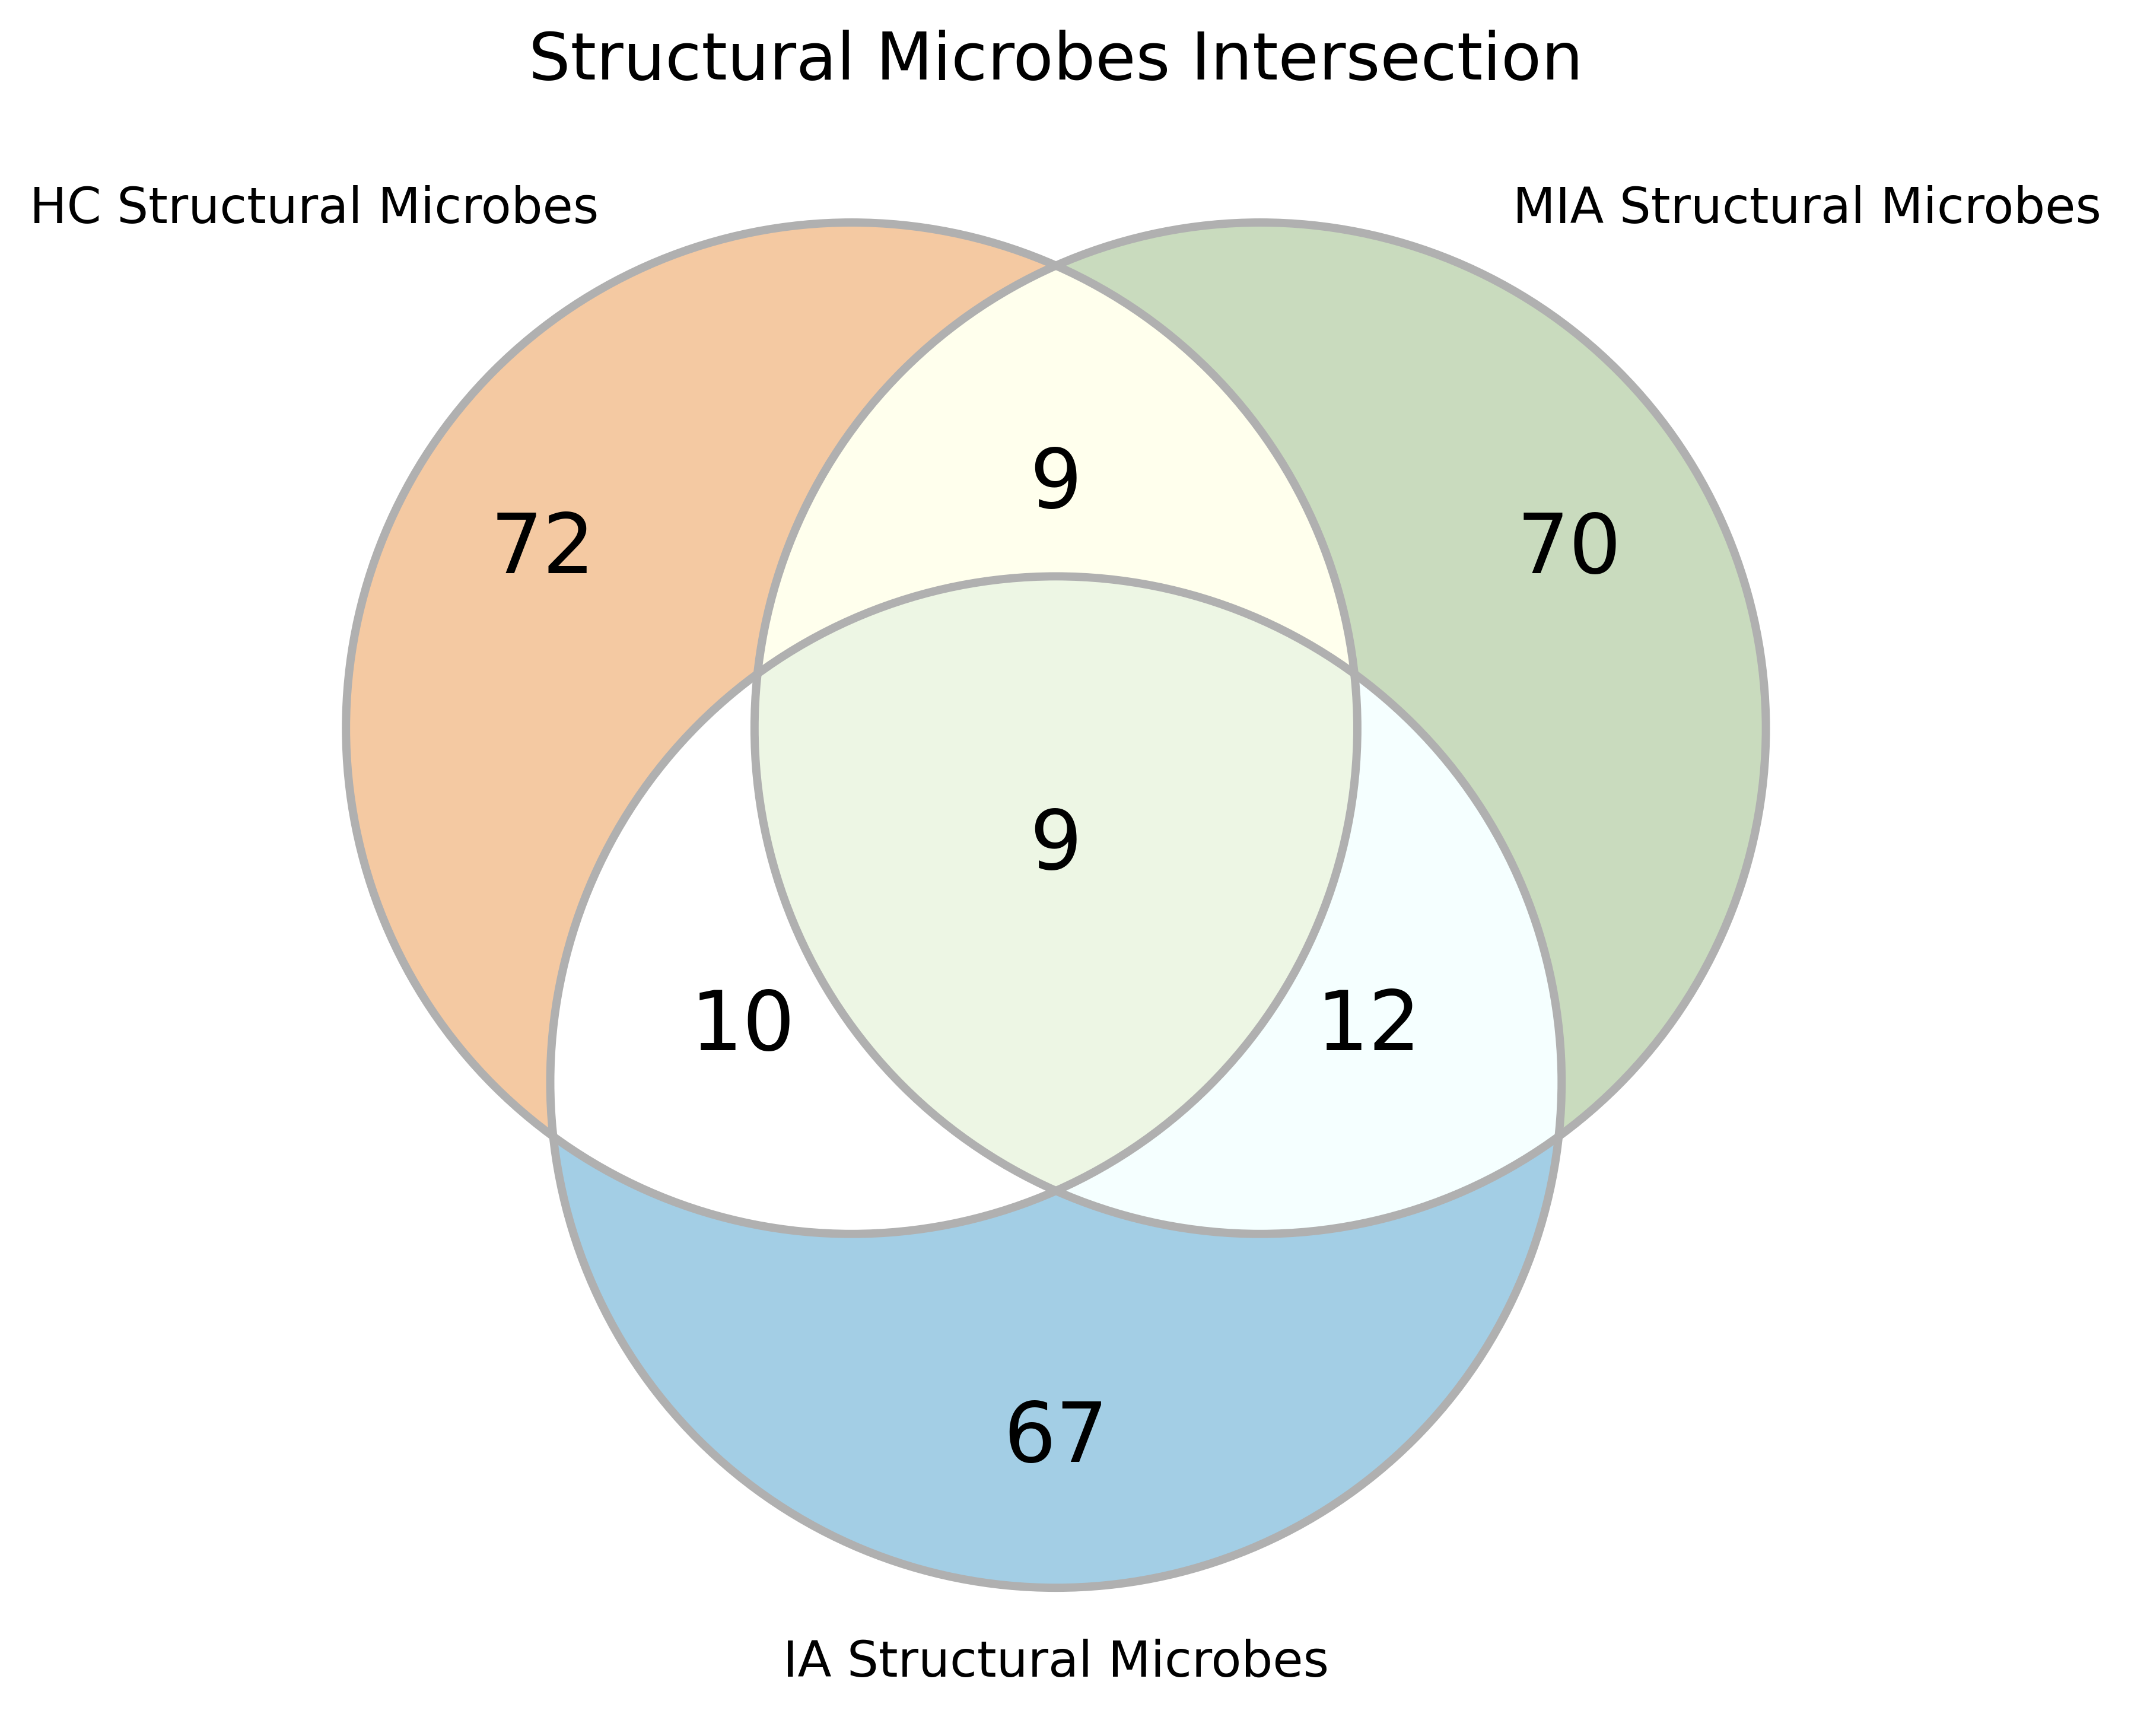

In [12]:
# Overlap of three microbial STGs
mb_overlap_st = plot_venn3_equal_return(structure_mb['HC'], structure_mb['MIA'], structure_mb['IA'],
                            set1_label="HC Structural Microbes", set2_label="MIA Structural Microbes", set3_label="IA Structural Microbes",
                            title="Structural Microbes Intersection",
                            )

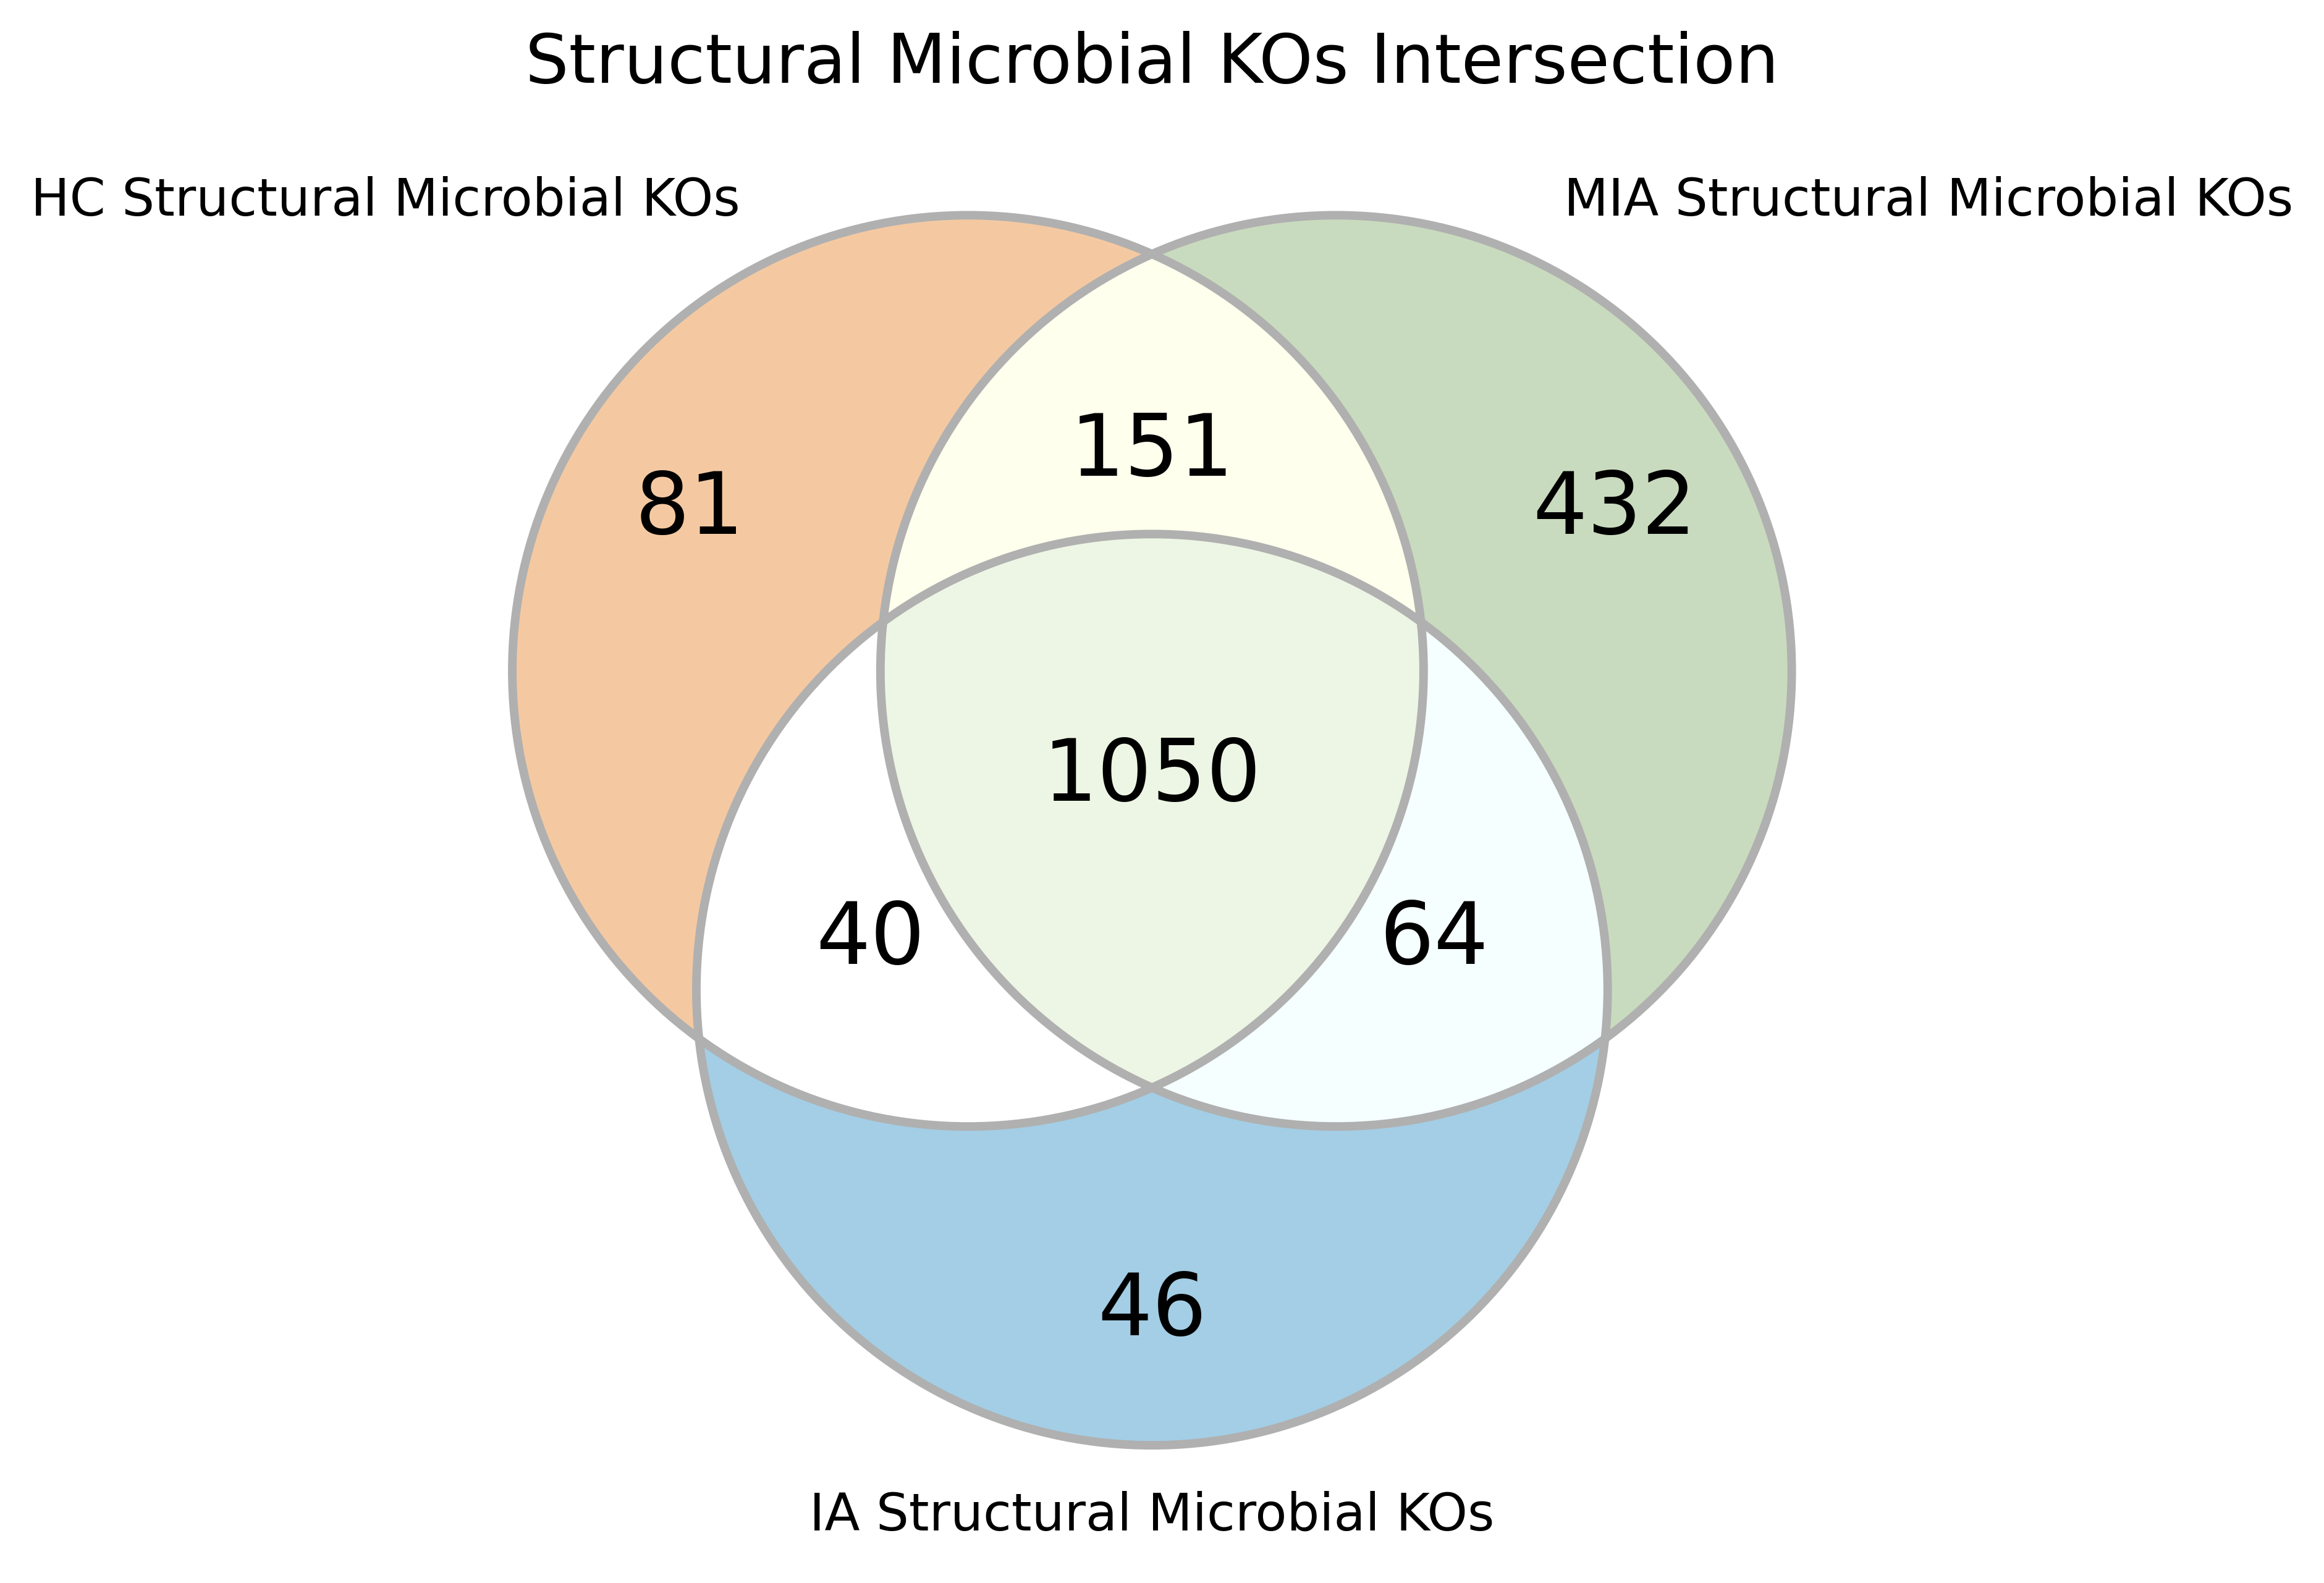

In [13]:
# Overlap of three microbial STGs' KOs
st_hc_ko = st_mb_ko['HC']
st_mia_ko = st_mb_ko['MIA']
st_ia_ko = st_mb_ko['IA']
elements = plot_venn3_equal_return(st_hc_ko,st_mia_ko,st_ia_ko,
                            set1_label="HC Structural Microbial KOs", set2_label="MIA Structural Microbial KOs", set3_label="IA Structural Microbial KOs",
                            title="Structural Microbial KOs Intersection",
                                  )

### Load KO relative abundance 

In [14]:
# KO file should be processed by CLR
df_anno_mt_clean_clr = pd.read_csv('data/all_ko_mt_clr.csv',index_col=0)
df_anno_mt_clean_clr.index = df_mb.index

In [16]:
st_ko = ordered_union(st_hc_ko,st_mia_ko,st_ia_ko)
df_anno_mt_clean_clr_st = df_anno_mt_clean_clr[st_ko ]

In [17]:
df_anno_mt_clean_clr_st

,K17214,K01278,K11753,K00558,K01845,K00878,K01785,K01788,K00705,K00041,...,K15921,K11953,K00395,K14446,K01728,K06164,K00015,K08068,K00209,K14983
Sample,,,,,,,,,,,,,,,,,,,,,
HC,5.323973,8.539435,9.609421,10.618970,8.745017,8.841533,9.887198,8.691573,10.057163,9.296286,...,6.079196,-9.746615,8.625343,-9.746615,5.265369,6.691664,6.499669,3.076703,6.284209,6.366488
HC,5.443327,9.477642,9.356385,10.104180,8.149939,8.600339,10.032117,8.150861,9.779212,9.000004,...,7.882076,-9.974301,7.843932,2.090767,1.168938,6.086882,6.368351,3.563429,6.462128,4.356721
HC,6.007409,8.866342,9.333920,10.161564,8.734884,8.914227,9.571514,8.475434,9.830464,8.596028,...,5.910617,-10.124448,8.097203,-10.124448,0.386314,5.092701,0.359285,5.357152,7.128655,3.946704
HC,5.568330,10.926462,10.411138,10.907688,8.065163,8.420426,10.464417,7.752872,10.721578,9.213188,...,4.495780,-9.211119,6.760148,-9.211119,6.701929,6.100795,6.671698,-9.211119,6.977553,3.852919
HC,5.338220,7.090888,7.545346,7.906536,7.568285,7.018670,8.058446,7.232493,7.512174,6.561723,...,3.292423,-11.686195,2.926894,-11.686195,4.670295,6.596063,2.158866,-0.539789,6.173102,4.881938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IA,1.543305,6.139321,6.503772,7.440175,5.472610,5.840444,6.630486,5.122214,6.753319,5.568114,...,1.926319,-12.854905,4.064970,0.671287,-12.854905,4.701485,1.439959,-0.162400,3.183516,-0.268383
IA,5.703717,8.498832,8.646526,9.778642,7.645727,8.274575,8.947828,7.336739,8.975094,7.808252,...,6.041783,-10.684902,6.556666,-10.684902,-0.239190,4.948687,5.279073,4.170433,4.846953,1.079867
IA,5.620203,8.300854,8.496662,9.517658,7.953912,8.069864,8.910257,7.408807,9.066056,7.819014,...,5.538751,-10.836178,7.433477,-10.836178,1.855036,5.451124,5.733220,3.690538,6.190117,2.438153


# -----WGCNA analysis process-----

### Load WGCNA results

In [18]:
# Load WGCNA results
wgcna_gl_cor_df = pd.read_csv('data/module_disease_correlation.csv')
wgcna_gl_module_df = pd.read_csv('data/KO_module_assignment.csv')

df_mb = pd.read_csv('data/microbe_train.csv',index_col=0)

In [19]:
wgcna_gl_cor = {'pos':['blue'],'neg':['turquoise','brown','green']}

In [20]:
wgcna_gl_module = {}
for idx,df in wgcna_gl_module_df.groupby(['Module']):
    wgcna_gl_module[idx] = df['KO'].to_list()

In [21]:
df_anno_mt_module_paint = pd.DataFrame()
def module_concat(df,module):
    _mt = df.T.loc[wgcna_gl_module[module]]
    _mt.index = [module.capitalize()]*len(_mt)
    return _mt
for module in wgcna_gl_cor_df[wgcna_gl_cor_df['Significant']=='Yes']['Module']:
    df_anno_mt_module_paint = pd.concat([df_anno_mt_module_paint,module_concat(df_anno_mt_clean_clr[st_ko],module)])

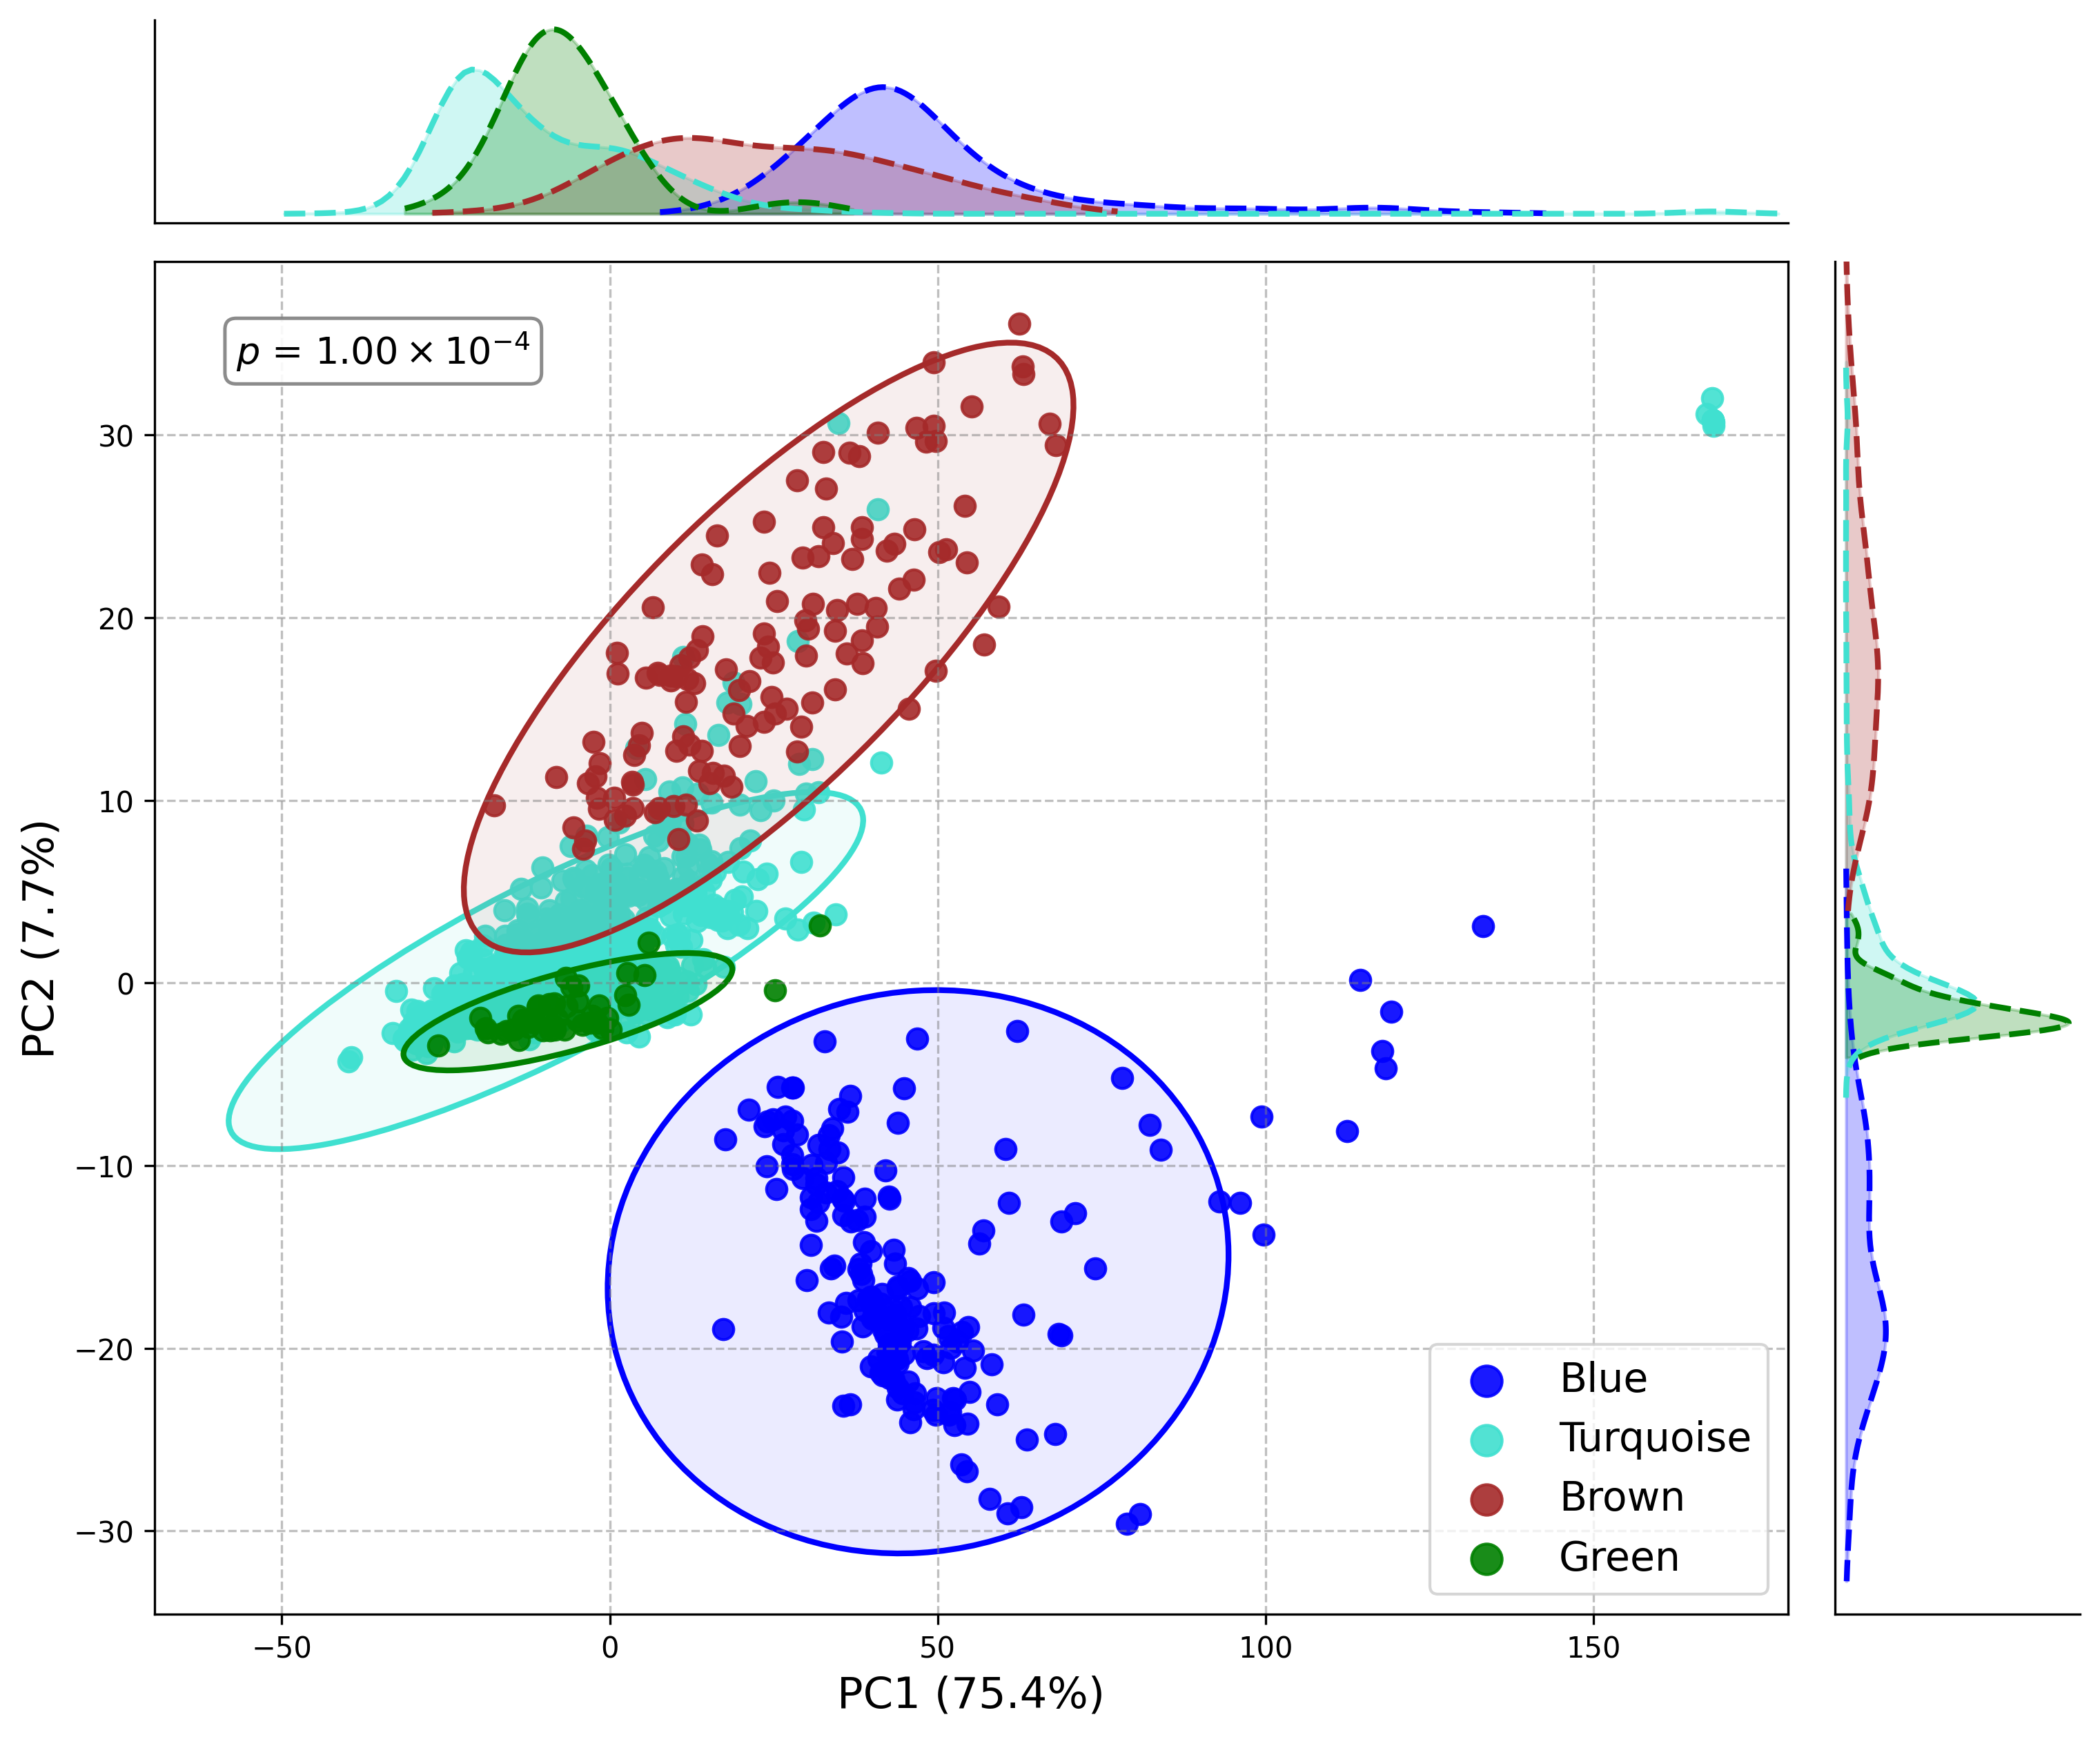

In [22]:
from core.plot_samples import visualize_common_features_samples
color_dict = {
    'Blue': '#0000FF',
    'Brown': '#A52A2A',
    'Green': '#008000',
    'Turquoise': '#40E0D0',
}
visualize_common_features_samples(df_anno_mt_module_paint, 
                                      features=None,
                                      group=['Blue', 'Turquoise', 'Brown','Green'],
                                   scale=None,
                                      method='pca', 
                                      random_state=42, 
                                      colors=color_dict, 
                                  marker = 'o',
                                      confidence_level=0.95,
                                      test_on_original=True,
                                      )
plt.show()

### KO modules' similarity across six external datasets

In [ ]:
TUK = pd.read_csv('data/other_ref/AT',sep='\t',index_col=0)
CHD = pd.read_csv('data/other_ref/CC',sep='\t',index_col=0)
PMW = pd.read_csv('data/other_ref/BMD.tsv',sep='\t',index_col=0)
CD = pd.read_csv('data/other_ref/CD.profile',sep='\t',index_col=0)
AVCD = pd.read_csv('data/other_ref/ACD.profile',sep='\t',index_col=0)
SMI = pd.read_csv('data/other_ref/MOM',sep='\t',index_col=0)

In [25]:
disease_names = ['CD','AVCD','PMW','TUK','CHD','SMI']
disease_dfs = [CD,AVCD,PMW,TUK,CHD,SMI]

In [26]:
from core import ko_sim

results_list = []
print("Starting Distance-Based Bootstrap Analysis...")

for module, kos in tqdm(wgcna_gl_module.items()):
    
    valid_luad_kos = [k for k in kos if k in df_anno_mt_clean_clr.columns]
    if len(valid_luad_kos) < 3:
        continue

    luad_module_corr = df_anno_mt_clean_clr[valid_luad_kos].corr(method='spearman')
    
    for d_name, d_df in zip(disease_names, disease_dfs):
        try:
            obs_r, boot_mean, ci_2_5, ci_97_5, n_hits = ko_sim.co_shift_bootstrap_distance(
                d_df, 
                valid_luad_kos, 
                luad_module_corr, 
                n_boot=100, 
                seed=42
            )
            
            if np.isnan(obs_r):
                continue

            results_list.append({
                'Module': module,
                'Disease': d_name,
                'N_Features': n_hits,
                'R_Observed': obs_r,
                'R_Boot_Mean': boot_mean,
                'CI_Low': ci_2_5,
                'CI_High': ci_97_5,
           
                'Stability': 'Robust' if (ci_2_5 > 0) else 'Unstable'
            })
            
        except Exception as e:
            print(f"Error in {module} - {d_name}: {e}")


df_res = pd.DataFrame(results_list)


Starting Distance-Based Bootstrap Analysis...


100%|██████████| 6/6 [15:15<00:00, 152.54s/it]


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Plot style
sns.set_style("whitegrid", {
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2,
    'grid.color': '#E5E5E5',
    'xtick.direction': 'out',
    'ytick.direction': 'out'
})

# Data preparation
disease_order = ['CD', 'AVCD', 'PMW', 'TUK', 'CHD', 'SMI']

df_plot = df_res.copy()
df_plot = df_plot[df_plot['Module'] != 'grey']
df_plot = df_plot[df_plot['Module'] != 'yellow']
df_plot = df_plot[df_plot['Disease'] != 'IND']

df_plot['Disease'] = pd.Categorical(df_plot['Disease'], categories=disease_order, ordered=True)
df_plot = df_plot.sort_values(['Module', 'Disease'])

unique_modules = df_plot['Module'].unique()
module_color_dict = {m: m for m in unique_modules}

# Main plot
plt.figure(figsize=(35, 8), dpi=500)

sns.lineplot(
    data=df_plot,
    x='Disease',
    y='R_Boot_Mean',
    hue='Module',
    style='Module',
    markers=True,
    dashes=False,
    linewidth=5,
    markersize=15,
    palette=module_color_dict,
    zorder=2
)

# Error bars
x_map = {name: i for i, name in enumerate(disease_order)}

for module_name in unique_modules:
    subset = df_plot[df_plot['Module'] == module_name]

    if subset.empty:
        continue

    lower_err = subset['R_Boot_Mean'] - subset['CI_Low']
    upper_err = subset['CI_High'] - subset['R_Boot_Mean']
    x_coords = subset['Disease'].map(x_map)

    plt.errorbar(
        x=x_coords,
        y=subset['R_Boot_Mean'],
        yerr=[lower_err, upper_err],
        fmt='none',
        ecolor=module_color_dict[module_name],
        elinewidth=1.5,
        capsize=5,
        alpha=0.8,
        zorder=3
    )

# Reference line and labels
plt.axhline(y=0, color='black', linewidth=1, alpha=0.5)

plt.title('Correlation of WGCNA Modules Across Diseases (with Bootstrap CI)', fontsize=16, pad=20)
plt.xlabel('Disease Dataset', fontsize=14)
plt.ylabel('Bootstrap Mean Correlation (Mental r)', fontsize=14)

plt.xticks(rotation=45, ha='right')

# Legend
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Module')

plt.tight_layout()
plt.show()

### Mean correlation change across stages

In [38]:
dfs = {
    'HC':df_anno_mt_clean_clr.loc[
    [i for i in df_anno_mt_clean_clr.index if 'HC' in i],
    st_ko
],
  'MIA':df_anno_mt_clean_clr.loc[
    [i for i in df_anno_mt_clean_clr.index if 'MIA' in i],
    st_ko
]  ,
    'IA':
    df_anno_mt_clean_clr.loc[
    [i for i in df_anno_mt_clean_clr.index if 'IA' in i],
    st_ko
]
}

In [39]:
import numpy as np
import pandas as pd
import itertools


def compute_module_connectivity(dfs, module_dict, pos_modules=None, neg_modules=None):
    """
    Compute quantitative metrics for intra-module and inter-module connectivity
    using all available pairs.

    Supported summary categories:
        pos_intra : intra-module cohesion within positive modules
        neg_intra : intra-module cohesion within negative modules
        pos_inter : inter-module crosstalk among positive modules
        neg_inter : inter-module crosstalk among negative modules
        pos_neg   : inter-module crosstalk between positive and negative modules

    Returns:
        summary_df, pairwise_df
    """

    # Build node list
    all_cols = set()
    for df in dfs.values():
        all_cols.update(df.columns)

    node_names = []
    node_colors = []
    target_modules = [m for m in module_dict.keys() if m != 'grey' and m != 'red']

    for mod in target_modules:
        kos_in_mod = [k for k in module_dict[mod] if k in all_cols]
        if not kos_in_mod:
            continue
        clean_color = mod.replace('ME', '')
        node_names.extend(kos_in_mod)
        node_colors.extend([clean_color] * len(kos_in_mod))

    node_colors_arr = np.array(node_colors)
    unique_mods = sorted(set(node_colors))

    print(f"Total nodes: {len(node_names)}")
    print(f"Included modules: {unique_mods}")

    all_pairwise = []
    all_summary = []

    for group_name, df in dfs.items():
        print(f"\n--> Computing: {group_name}")

        df_aligned = df.reindex(columns=node_names).fillna(0)
        corr = df_aligned.corr(method='spearman').fillna(0).values
        con_abs = np.abs(corr)
        np.fill_diagonal(con_abs, 0)

        # Inter-module matrix
        mask_inter = node_colors_arr[:, None] != node_colors_arr[None, :]
        con_inter = con_abs.copy()
        con_inter[~mask_inter] = 0

        # Pairwise inter-module statistics
        for mod_a, mod_b in itertools.combinations(unique_mods, 2):
            idx_a = np.where(node_colors_arr == mod_a)[0]
            idx_b = np.where(node_colors_arr == mod_b)[0]
            sub = con_inter[np.ix_(idx_a, idx_b)]
            all_pairwise.append({
                'group': group_name,
                'type': 'inter',
                'module_a': mod_a,
                'module_b': mod_b,
                'n_possible': sub.size,
                'mean_corr': np.mean(sub) if sub.size > 0 else 0,
                'median_corr': np.median(sub) if sub.size > 0 else 0,
                'max_corr': np.max(sub) if sub.size > 0 else 0,
                'n_links': sub.size,
                'mean_corr_links': np.mean(sub) if sub.size > 0 else 0,
                'proportion': 1.0 if sub.size > 0 else 0,
            })

        # Pairwise intra-module statistics
        for mod in unique_mods:
            idx = np.where(node_colors_arr == mod)[0]
            if len(idx) < 2:
                continue
            sub = con_abs[np.ix_(idx, idx)]
            np.fill_diagonal(sub, 0)
            triu = sub[np.triu_indices_from(sub, k=1)]
            all_pairwise.append({
                'group': group_name,
                'type': 'intra',
                'module_a': mod,
                'module_b': mod,
                'n_possible': len(triu),
                'mean_corr': np.mean(triu) if len(triu) > 0 else 0,
                'median_corr': np.median(triu) if len(triu) > 0 else 0,
                'max_corr': np.max(triu) if len(triu) > 0 else 0,
                'n_links': len(triu),
                'mean_corr_links': np.mean(triu) if len(triu) > 0 else 0,
                'proportion': 1.0 if len(triu) > 0 else 0,
            })

        if pos_modules or neg_modules:
            pos_modules = pos_modules or []
            neg_modules = neg_modules or []

            def _intra_stats(mod_list):
                vals = []
                nl, np_ = 0, 0
                for mod in mod_list:
                    idx = np.where(node_colors_arr == mod)[0]
                    if len(idx) < 2:
                        continue
                    sub = con_abs[np.ix_(idx, idx)]
                    np.fill_diagonal(sub, 0)
                    triu = sub[np.triu_indices_from(sub, k=1)]
                    vals.append(triu)
                    nl += len(triu)
                    np_ += len(triu)
                if vals:
                    c = np.concatenate(vals)
                else:
                    c = np.array([])
                return c, int(nl), int(np_)

            def _inter_stats(pairs):
                vals = []
                nl, np_ = 0, 0
                for ma, mb in pairs:
                    idx_a = np.where(node_colors_arr == ma)[0]
                    idx_b = np.where(node_colors_arr == mb)[0]
                    if len(idx_a) == 0 or len(idx_b) == 0:
                        continue
                    sub = con_inter[np.ix_(idx_a, idx_b)]
                    vals.append(sub.flatten())
                    nl += sub.size
                    np_ += sub.size
                if vals:
                    c = np.concatenate(vals)
                else:
                    c = np.array([])
                return c, int(nl), int(np_)

            def _append(cat_name, combined, nl, np_):
                all_summary.append({
                    'group': group_name,
                    'category': cat_name,
                    'mean_corr': np.mean(combined) if len(combined) > 0 else 0,
                    'median_corr': np.median(combined) if len(combined) > 0 else 0,
                    'n_links': nl,
                    'n_possible': np_,
                    'proportion': nl / np_ if np_ > 0 else 0,
                    'mean_corr_links': np.mean(combined) if len(combined) > 0 else 0,
                })

            if len(pos_modules) >= 1:
                c, nl, np_ = _intra_stats(pos_modules)
                _append('pos_intra', c, nl, np_)

            if len(neg_modules) >= 1:
                c, nl, np_ = _intra_stats(neg_modules)
                _append('neg_intra', c, nl, np_)

            if len(pos_modules) >= 2:
                c, nl, np_ = _inter_stats(itertools.combinations(pos_modules, 2))
                _append('pos_inter', c, nl, np_)

            if len(neg_modules) >= 2:
                c, nl, np_ = _inter_stats(itertools.combinations(neg_modules, 2))
                _append('neg_inter', c, nl, np_)

            if len(pos_modules) >= 1 and len(neg_modules) >= 1:
                c, nl, np_ = _inter_stats(itertools.product(pos_modules, neg_modules))
                _append('pos_neg', c, nl, np_)

    pairwise_df = pd.DataFrame(all_pairwise)
    summary_df = pd.DataFrame(all_summary) if all_summary else pd.DataFrame()

    return summary_df, pairwise_df

In [40]:
summary, pairwise = compute_module_connectivity(
    dfs,
    wgcna_gl_module,
    pos_modules=['blue'],
    neg_modules=['turquoise', 'brown', 'green'],
)

Total nodes: 1670
Included modules: ['blue', 'brown', 'green', 'turquoise', 'yellow']

--> Computing: HC

--> Computing: MIA

--> Computing: IA


Available categories: ['pos_intra', 'neg_intra', 'neg_inter', 'pos_neg']


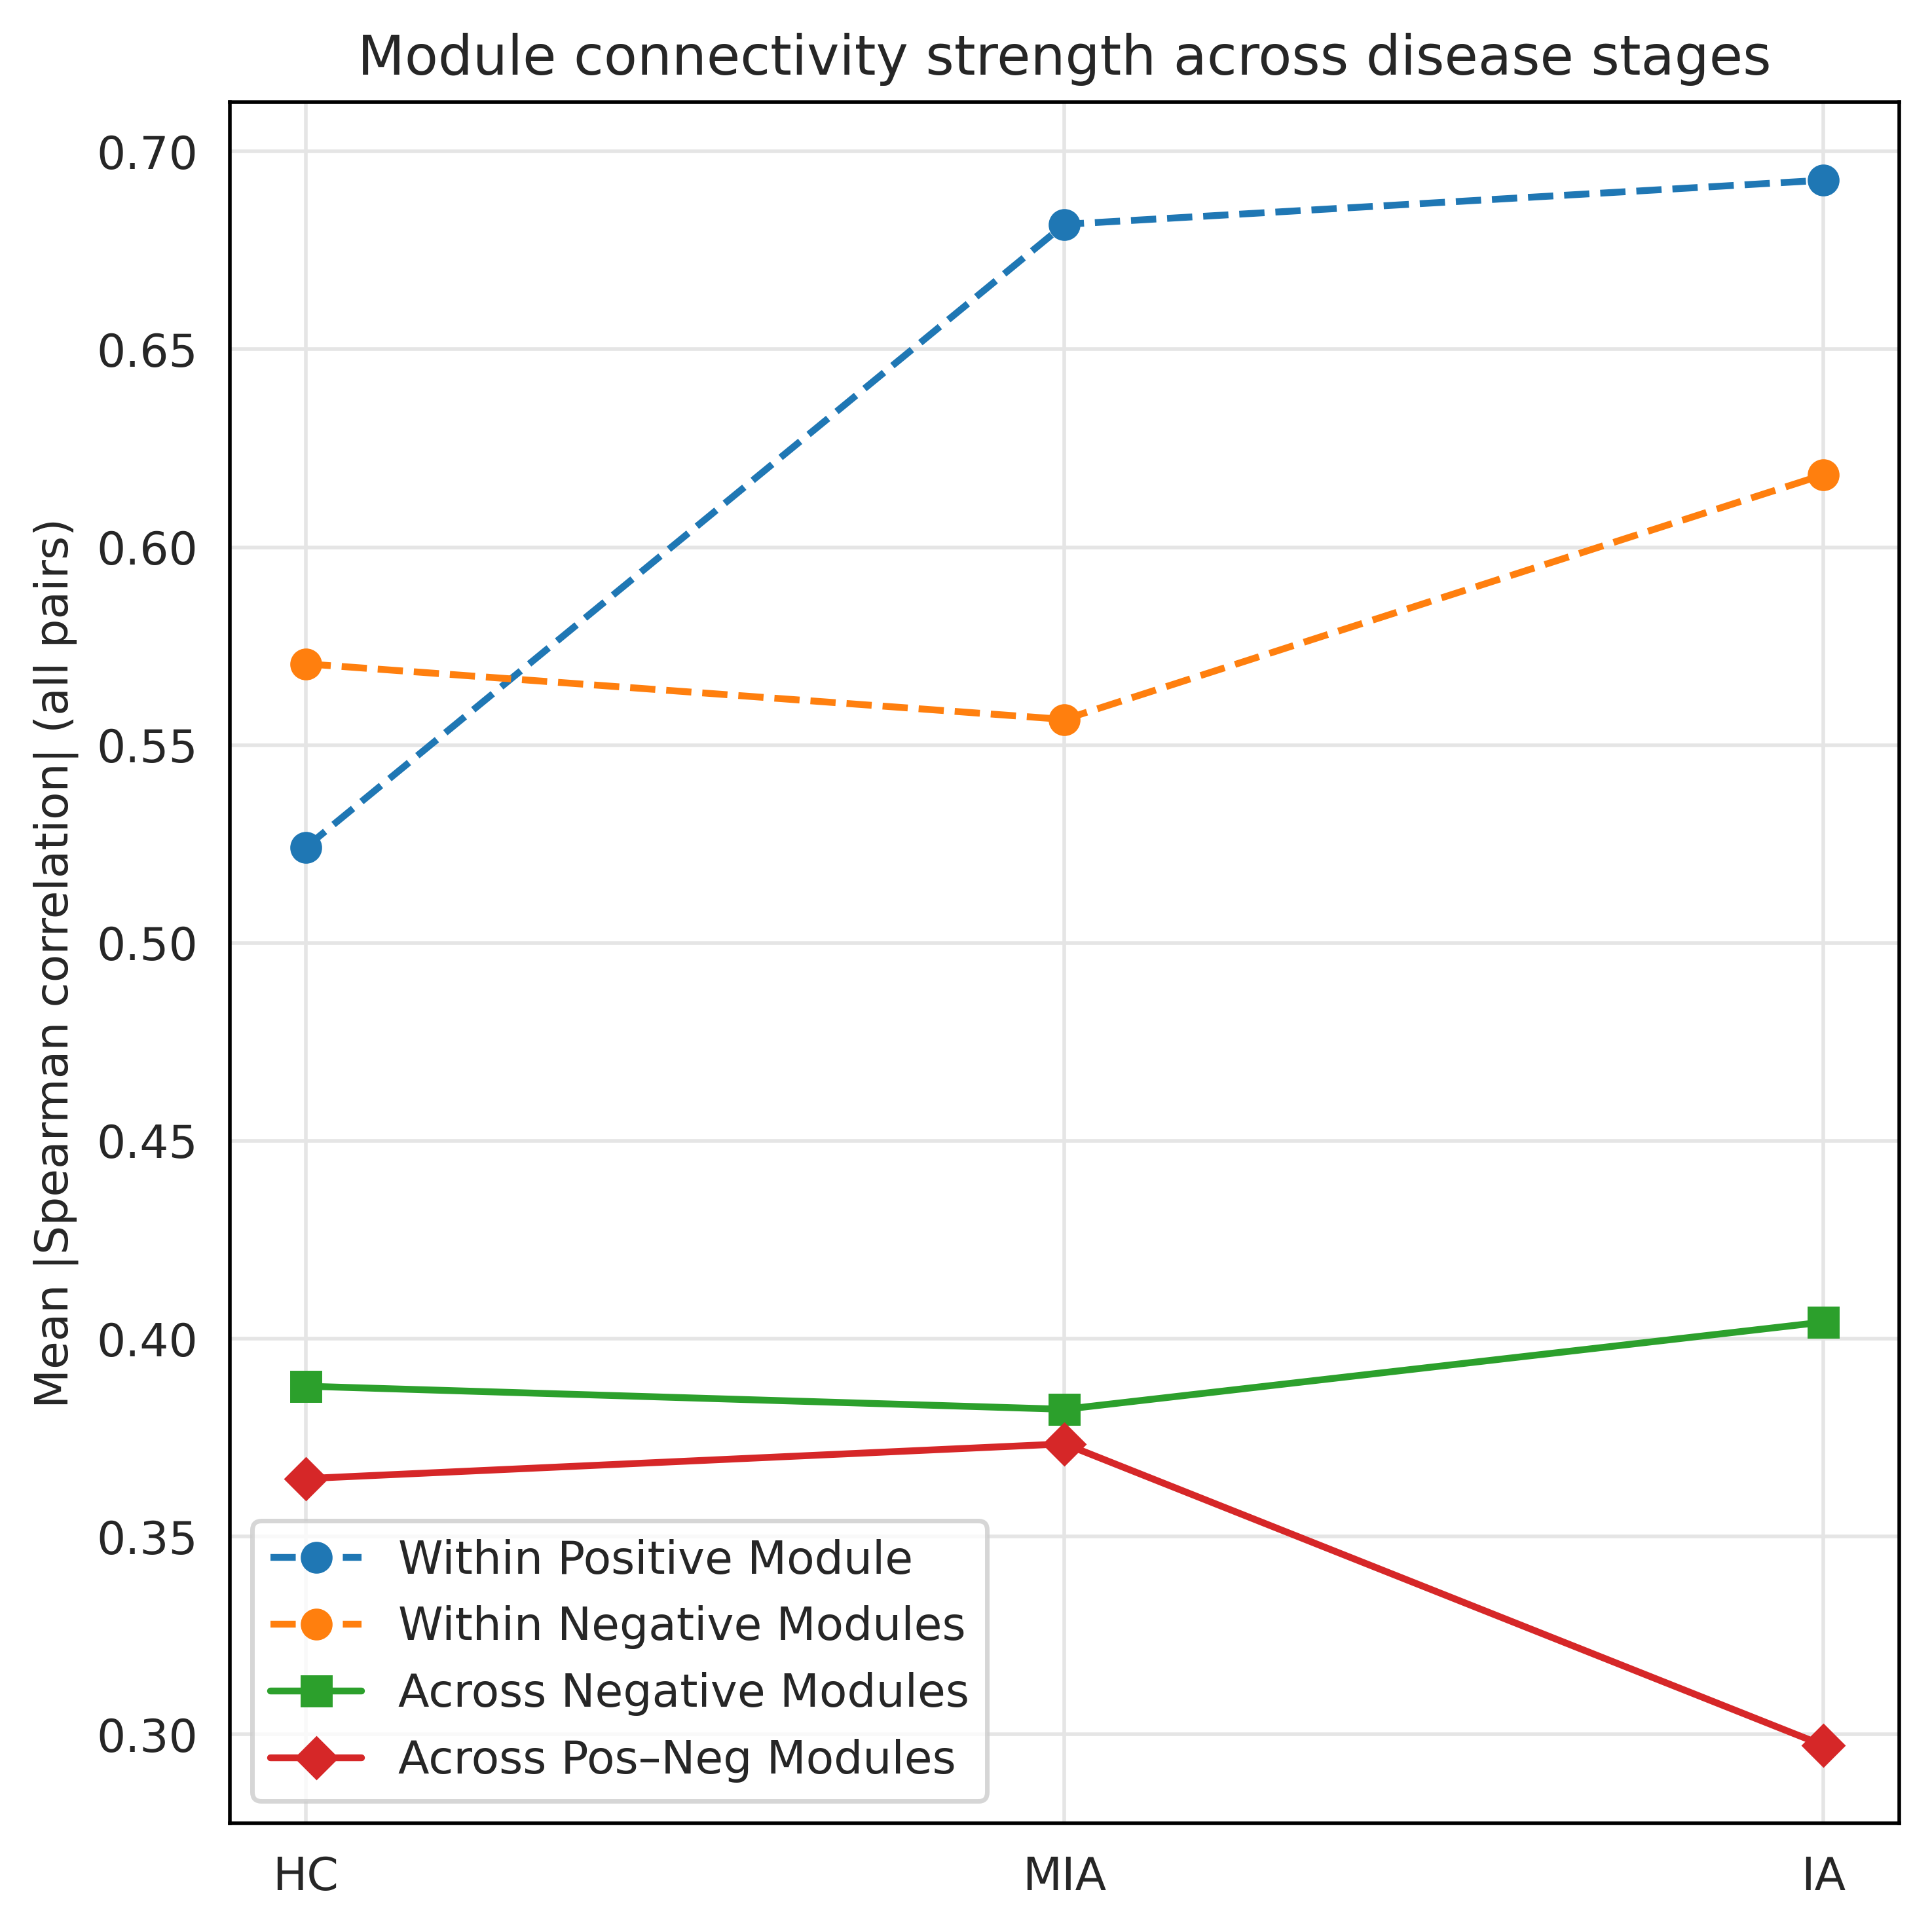

In [41]:
# Get available categories dynamically
available_cats = summary['category'].unique().tolist()
print(f"Available categories: {available_cats}")

fig, axes = plt.subplots(1, 1, figsize=(6, 6), dpi=500)

# Legend labels
label_map = {
    'pos_intra': 'Within Positive Module',
    'neg_intra': 'Within Negative Modules',
    'pos_inter': 'Across Positive Modules',
    'neg_inter': 'Across Negative Modules',
    
    'pos_neg':   'Across Pos–Neg Modules',
}

# Plot styles
style_map = {
    'pos_intra':  {'marker': 'o', 'ls': '--'},
    'neg_intra':  {'marker': 'o', 'ls': '--'},
    'pos_inter':  {'marker': 's', 'ls': '-'},
    'neg_inter':  {'marker': 's', 'ls': '-'},
    'pos_neg':    {'marker': 'D', 'ls': '-'},
}

for cat in available_cats:
    sub = summary[summary['category'] == cat]
    st = style_map.get(cat, {'marker': 'x', 'ls': '-'})
    label = label_map.get(cat, cat)

    axes.plot(
        sub['group'], sub['mean_corr'],
        marker=st['marker'], ls=st['ls'],
        label=label
    )

axes.set_ylabel('Mean |Spearman correlation| (all pairs)')
axes.set_title('Module connectivity strength across disease stages')
axes.legend(loc='lower left')
axes.tick_params(axis='x')

plt.tight_layout()
plt.show()